# Task 1: Dimensionality Reduction on Hydrogen Tweets Dataset

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D 


Task 1: Prepare the dataset

In [8]:
# set random seed
random_seed = 42

In [9]:
# Load data
X = pd.read_csv("Datasets/tfidf_features.csv")

In [10]:
n_samples, n_dims = X.shape
print(f"TF-IDF matrix shape: {n_samples:,} samples × {n_dims:,} dimensions")

TF-IDF matrix shape: 2,500 samples × 8,968 dimensions


In [11]:
# Connect labels
labels = pd.read_csv("Datasets/hydrogen.csv")
y = labels["label"].values

In [12]:
# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

Task 2: The curse of high dimensionality

In [13]:
dims = [2, 5, 10, 20, 50, 100, 200, 300, 500, 800, 1000, 1500, 2000, 3000, 5000, n_dims]

In [14]:
# Shuffle the features randomly to avoid bias for first features
rng = np.random.default_rng(random_seed)
perm = rng.permutation(n_dims)
X_perm = X[:, perm]

In [15]:
nearest_means   = []
tenth_means     = []
furthest_means  = []

for d in dims:
    Xd = X_perm[:, :d]
    D = pairwise_distances(Xd, metric="euclidean", n_jobs=-1)

    # Nearest neighbor
    np.fill_diagonal(D, np.inf)
    nearest = D.min(axis=1)

    # Distance to neighbor #10
    tenth = np.partition(D, kth=9, axis=1)[:, 9]

    # Furthest neighbor
    np.fill_diagonal(D, -np.inf)
    furthest = D.max(axis=1)

    nearest_means.append(float(nearest.mean()))
    tenth_means.append(float(tenth.mean()))
    furthest_means.append(float(furthest.mean()))

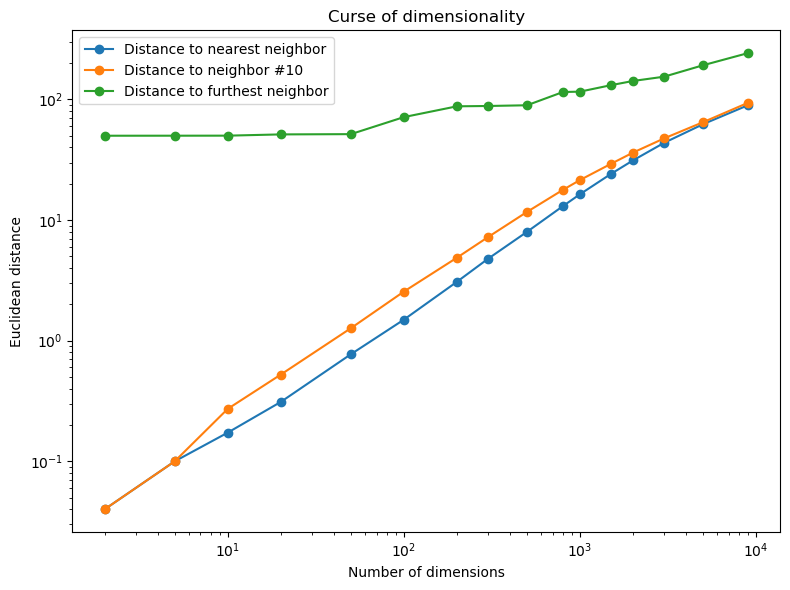

In [16]:
# Plot
plt.figure(figsize=(8,6))
plt.xscale("log"); plt.yscale("log")

plt.plot(dims, nearest_means,  "-o", label="Distance to nearest neighbor")
plt.plot(dims, tenth_means,    "-o", label="Distance to neighbor #10")
plt.plot(dims, furthest_means, "-o", label="Distance to furthest neighbor")

plt.xlabel("Number of dimensions")
plt.ylabel("Euclidean distance")
plt.title("Curse of dimensionality")
plt.legend()
plt.tight_layout()
plt.savefig("Outputs/curse_of_dimensionality.png", dpi=180)
plt.show()

Task 3: PCA

In [17]:
# Method: cumulative explained variance
comps_num = np.arange(1, n_samples+1, 100)
comps_variance = []

for k in comps_num:
    pca = PCA(n_components=k, random_state=random_seed)
    pca.fit(X)

    total_explained_variance = sum(pca.explained_variance_ratio_)
    comps_variance.append(total_explained_variance)


Following the Tutorial the optimal number of components is reached at 80-95%. We take the lowest threshold (80%) here as it already takes this many components.

In [22]:
# We did a finer analysis before where we got the result k80 = 1330, but here we just used stepsize =100, so we get a different result
comps_variance = np.array(comps_variance)
k80_idx = np.where(comps_variance >= 0.80)[0][0]
k80 = int(comps_num[k80_idx])
print(f"Smallest k for 80% variance: {k80}")

Smallest k for 80% variance: 1401


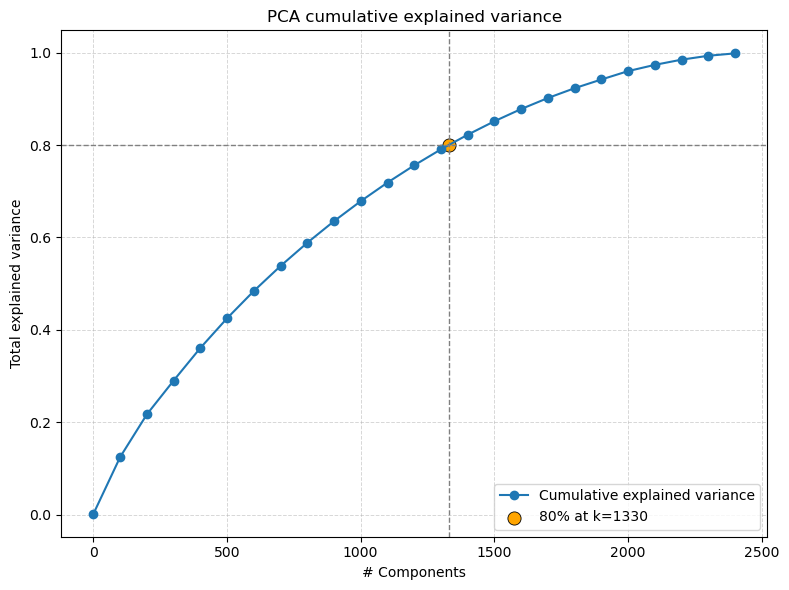

In [23]:
# Plot
k80 = 1330 # Set k80 to the optimal value from before
plt.figure(1, figsize=(8, 6))
plt.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.5)
plt.plot(comps_num, comps_variance, marker='o', label="Cumulative explained variance")
plt.xlabel("# Components")
plt.ylabel("Total explained variance")
plt.title("PCA cumulative explained variance")
plt.tight_layout()

# plot 80% threshold
plt.axhline(0.80, color='gray', ls='--', lw=1)
plt.axvline(k80,  color='gray', ls='--', lw=1)
plt.scatter([k80], [0.80], s=90, color='orange', edgecolor='k', linewidth=0.6, label=f"80% at k={k80}")

plt.legend(loc="lower right")
plt.savefig("Outputs/pca_elbow.png", dpi=180)
plt.show()

Method two: Cluster visualization (Drop it)
Doesn't make any sense since we can't plot more than three components at a time.


Explained variance ratio (Top 5 PCs):
  PC1: 0.0022
  PC2: 0.0022
  PC3: 0.0020
  PC4: 0.0020
  PC5: 0.0019
Total explained variance (Top 5): 0.0104


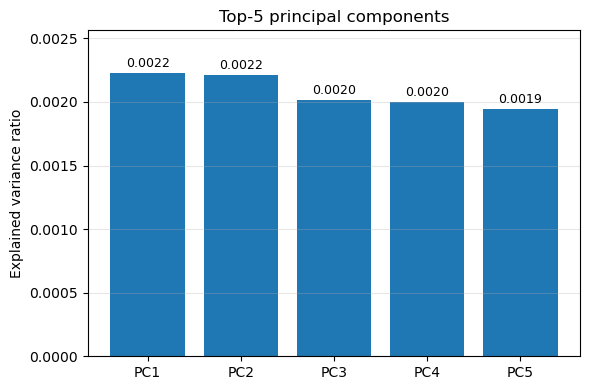

In [24]:
# Top five components
pca5 = PCA(n_components=5, random_state=random_seed).fit(X)
evr5 = pca5.explained_variance_ratio_

print("\nExplained variance ratio (Top 5 PCs):")
for i, v in enumerate(evr5, 1):
    print(f"  PC{i}: {v:.4f}")
print(f"Total explained variance (Top 5): {evr5.sum():.4f}")

Task 4: t-SNE

In [25]:
print(k80)

1330


In [26]:
X_pca = PCA(n_components=k80, random_state=random_seed).fit_transform(X) # PCA reduced dataset

# Reduce PCA reduced dataset to one, two and three components
kl_by_dim = {}
for d in [1, 2, 3]:
    tsne = TSNE(n_components=d, random_state=random_seed)
    X_tsne = tsne.fit_transform(X_pca)
    kl_by_dim[d] = float(tsne.kl_divergence_)

print("t-SNE KL divergence with default settings on PCA-reduced data:")
for d in [1, 2, 3]:
    print(f"  for {d} component(s): KL = {kl_by_dim[d]:.6f}")

t-SNE KL divergence with default settings on PCA-reduced data:
  for 1 component(s): KL = 3.444443
  for 2 component(s): KL = 2.693097
  for 3 component(s): KL = 2.902736


In [27]:
# As seen before 2 components is the best choice

# Determine optimal perplexity value
# Strategy: Try out all values between 5 and 50 as perplexity is between 5 and 50. (stepsize 5)

tsne_perplexity_num = np.arange(5, 50+1)
tsne_perplexity_divergence = []
for perplexity in tsne_perplexity_num:
    # Fit a TSNE model with 2 components.
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_seed)
    tsne.fit(X_pca)
    tsne_perplexity_divergence.append(tsne.kl_divergence_)
    print(f"KL Divergence for perplexity of {perplexity}: {tsne.kl_divergence_}")

KL Divergence for perplexity of 5: 2.782914161682129
KL Divergence for perplexity of 6: 2.863908290863037
KL Divergence for perplexity of 7: 2.9035348892211914
KL Divergence for perplexity of 8: 2.8891258239746094
KL Divergence for perplexity of 9: 2.9099035263061523
KL Divergence for perplexity of 10: 2.9210309982299805
KL Divergence for perplexity of 11: 2.9104526042938232
KL Divergence for perplexity of 12: 2.898746967315674
KL Divergence for perplexity of 13: 2.8930933475494385
KL Divergence for perplexity of 14: 2.8798627853393555
KL Divergence for perplexity of 15: 2.8865349292755127
KL Divergence for perplexity of 16: 2.885509967803955
KL Divergence for perplexity of 17: 2.8303630352020264
KL Divergence for perplexity of 18: 2.8436830043792725
KL Divergence for perplexity of 19: 2.8360538482666016
KL Divergence for perplexity of 20: 2.817758560180664
KL Divergence for perplexity of 21: 2.799206018447876
KL Divergence for perplexity of 22: 2.7703890800476074
KL Divergence for per

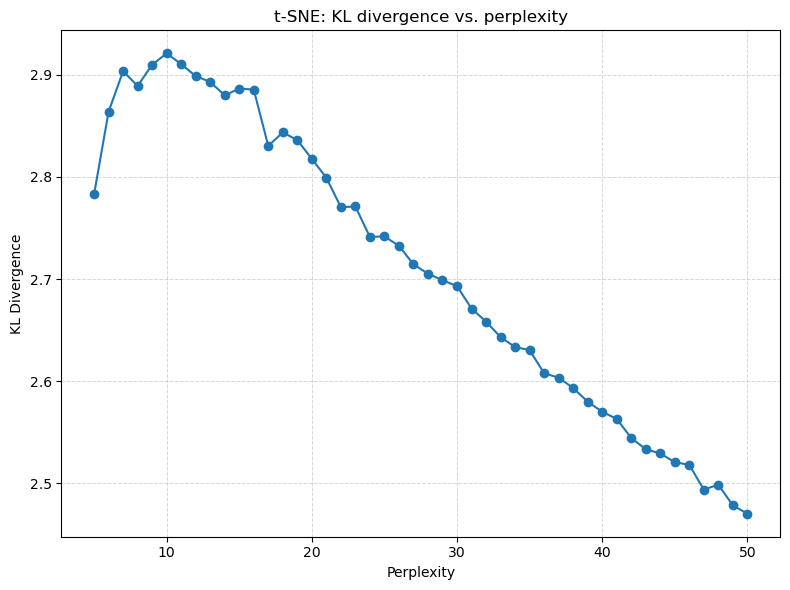

In [28]:
# Plot
plt.figure(1, figsize=(8, 6))
plt.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.5)
plt.plot(tsne_perplexity_num, tsne_perplexity_divergence, marker='o')
plt.xlabel("Perplexity")
plt.ylabel("KL Divergence")
plt.title("t-SNE: KL divergence vs. perplexity")
plt.tight_layout()
plt.savefig("Outputs/t_sne_plot.png", dpi=180)
plt.show()

selected perplexity: 50 since it has the lowest KL divergence

Task 5: Comparative Visualisation

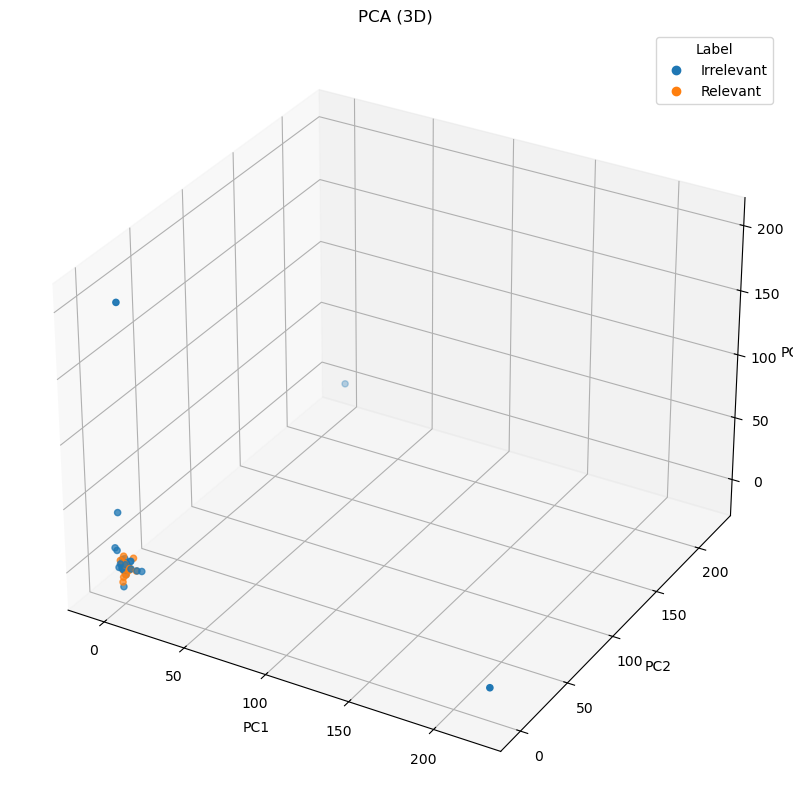

In [29]:
# Plot three Principal Components PCA
pca3 = PCA(n_components=3, random_state=random_seed).fit(X)
X_pca3 = pca3.transform(X)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection="3d")

# Paint "Irrelevant" in blue and "Relevant" in orange
palette = {"Irrelevant":"tab:blue", "Relevant":"tab:orange"}
colors = [palette[v] for v in y]
scatter = ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=colors, s=20)
ax.legend(handles=[Line2D([],[], marker='o', ls='', color=palette[k], label=k)
                   for k in palette], title="Label")

ax.set(xlabel="PC1", ylabel="PC2", zlabel="PC3")
plt.title("PCA (3D)")
plt.savefig("Outputs/PCA_three_PCs.png", dpi=180)
plt.show()

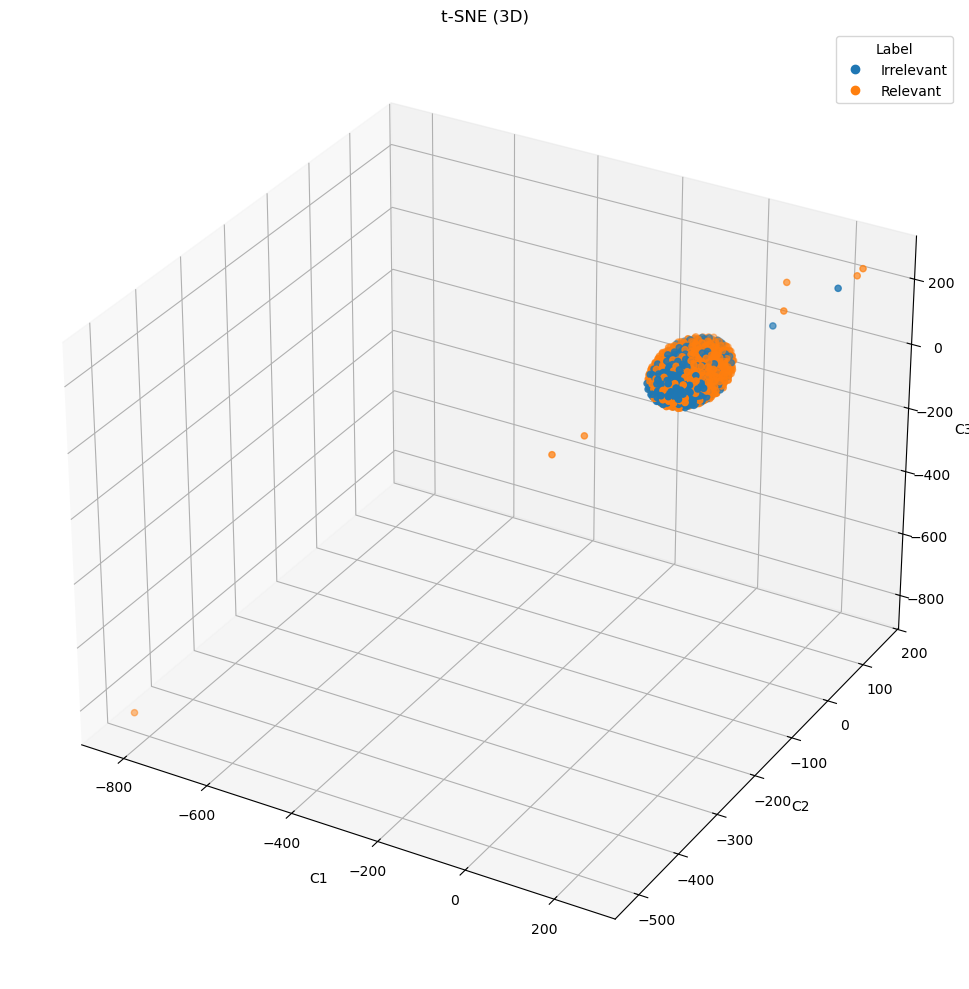

In [30]:
# Plot three Components for t-SNE
tsne3 = TSNE(n_components=3, perplexity=50, random_state=random_seed)
X_tsne3 = tsne3.fit_transform(X)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection="3d")

# Paint "Irrelevant" in blue and "Relevant" in orange
palette = {"Irrelevant": "tab:blue", "Relevant": "tab:orange"}
colors = [palette[v] for v in y]

scatter = ax.scatter(X_tsne3[:, 0], X_tsne3[:, 1], X_tsne3[:, 2],
                     c=colors, s=20)
ax.legend(handles=[Line2D([], [], marker='o', ls='', color=palette[k], label=k)
             for k in palette], title="Label")

ax.set(xlabel="C1", ylabel="C2", zlabel="C3")
plt.title("t-SNE (3D)")
plt.tight_layout()
plt.savefig("Outputs/TSNE_three_components.png", dpi=180)
plt.show()

# Task 2: Clustering the Kick dataset

In [21]:
#Load & initial preprocessing
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

random_state = 42

In [22]:
# not skipping empty values, to demonstrate data preprocessing steps later
df = pd.read_csv("Datasets/kick.csv", na_filter=False)
df.info()

# Summary statsics
print(df['VehOdo'].describe())
print(df['MMRAcquisitionAuctionAveragePrice'].describe())
print(df['WarrantyCost'].describe())
print(df['IsBadBuy'].value_counts())
print(df['Make'].value_counts())
print(df['Make'].unique())
print(df['IsBadBuy'].unique())

# Convert to numeric and handle blanks
df['VehOdo'] = df['VehOdo'].replace('', np.nan).astype(float)
df['MMRAcquisitionAuctionAveragePrice'] = df['MMRAcquisitionAuctionAveragePrice'].replace('', np.nan).astype(float)
df['WarrantyCost'] = df['WarrantyCost'].replace('', np.nan).astype(float)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41409 entries, 0 to 41408
Data columns (total 5 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   VehOdo                             41409 non-null  int64 
 1   MMRAcquisitionAuctionAveragePrice  41409 non-null  int64 
 2   Make                               41409 non-null  object
 3   WarrantyCost                       41409 non-null  int64 
 4   IsBadBuy                           41409 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 1.6+ MB
count     41409.000000
mean      71299.961868
std       14723.019112
min         577.000000
25%       61586.000000
50%       73128.000000
75%       82256.000000
max      480444.000000
Name: VehOdo, dtype: float64
count    41409.000000
mean      6135.010433
std       2481.223003
min          0.000000
25%       4273.000000
50%       6105.000000
75%       7783.000000
max      33543.000000
Name: MMRAcq

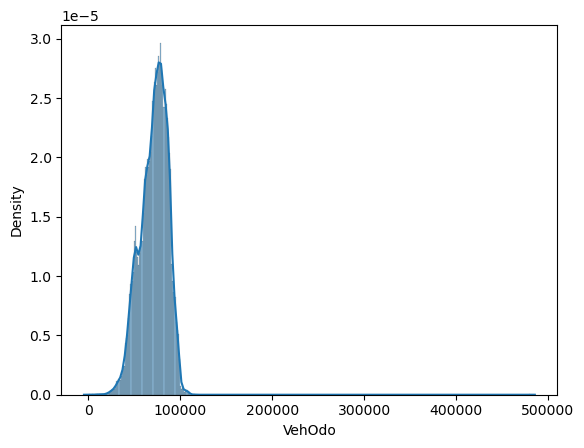

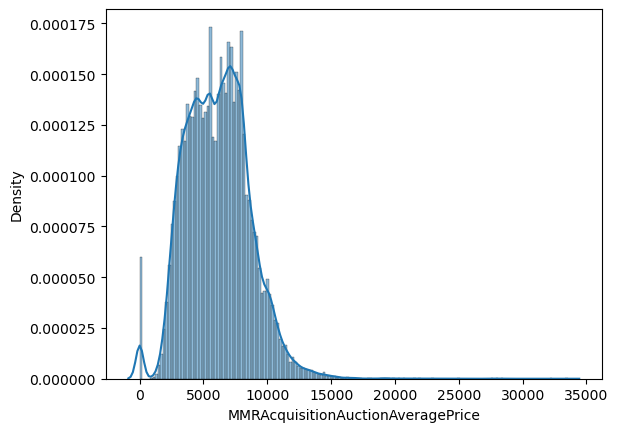

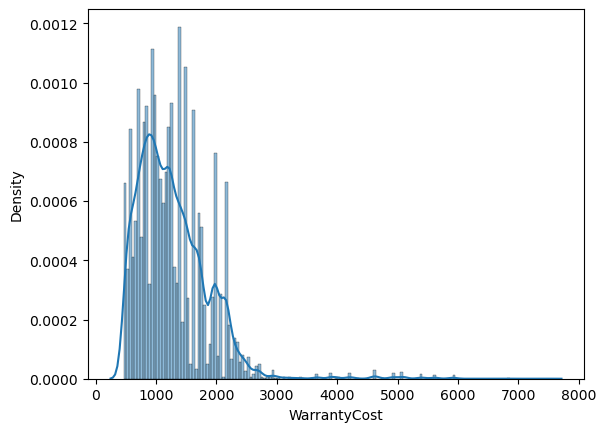

In [23]:
# Visualise distributions (before cleaning)

sns.histplot(df['VehOdo'].dropna(), kde=True, stat="density", kde_kws=dict(cut=3))
plt.show()

sns.histplot(df['MMRAcquisitionAuctionAveragePrice'].dropna(), kde=True, stat="density", kde_kws=dict(cut=3))
plt.show()

sns.histplot(df['WarrantyCost'].dropna(), kde=True, stat="density", kde_kws=dict(cut=3))
plt.show()

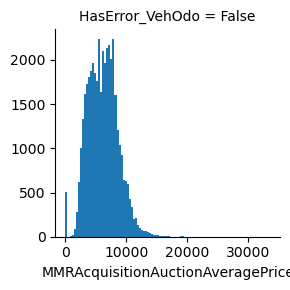

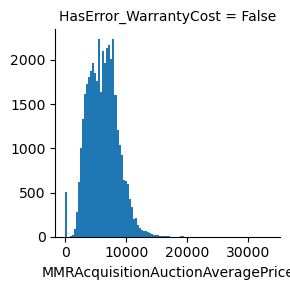

Row # before dropping erroneous rows 41409
Row # after dropping erroneous rows 40907


In [24]:
# Error flags and cleaning
df['HasError_VehOdo'] = df['VehOdo'] < 0
sns.FacetGrid(df, col='HasError_VehOdo').map(plt.hist, 'MMRAcquisitionAuctionAveragePrice', bins=100)
plt.show()

df['HasError_WarrantyCost'] = df['WarrantyCost'] <= 0
sns.FacetGrid(df, col='HasError_WarrantyCost').map(plt.hist, 'MMRAcquisitionAuctionAveragePrice', bins=100)
plt.show()

print("Row # before dropping erroneous rows", len(df))
df = df[df['VehOdo'] >= 0]
df = df[df['MMRAcquisitionAuctionAveragePrice'] > 0]
df = df[df['WarrantyCost'] >= 0]
df = df[df['Make'].notna()]
print("Row # after dropping erroneous rows", len(df))

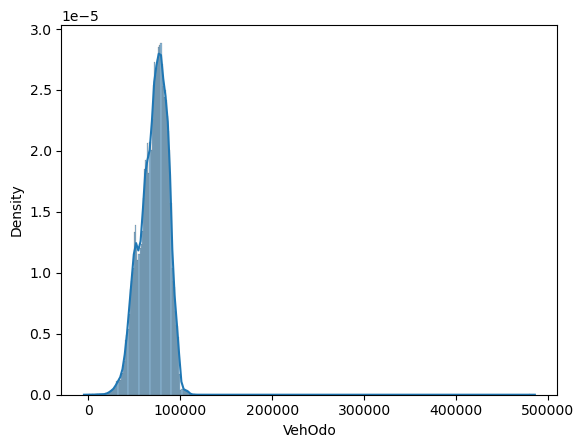

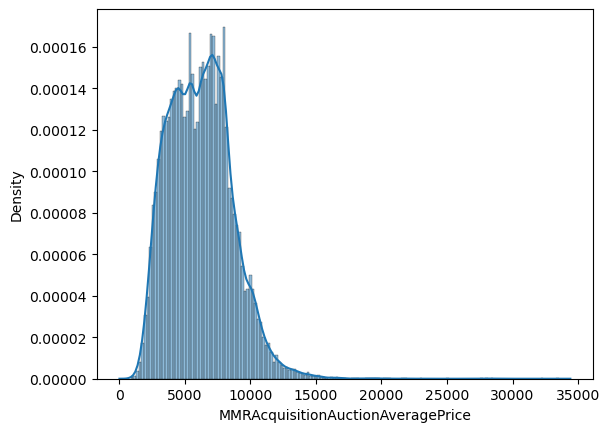

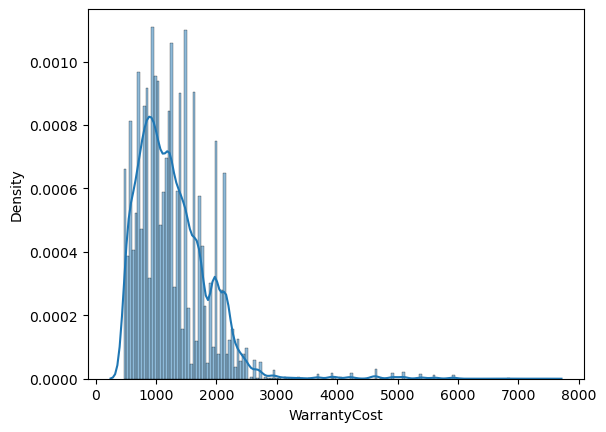

In [25]:
# Visualise distributions (after cleaning)
sns.histplot(df['VehOdo'].dropna(), kde=True, stat="density", kde_kws=dict(cut=3))
plt.show()

sns.histplot(df['MMRAcquisitionAuctionAveragePrice'].dropna(), kde=True, stat="density", kde_kws=dict(cut=3))
plt.show()

sns.histplot(df['WarrantyCost'].dropna(), kde=True, stat="density", kde_kws=dict(cut=3))
plt.show()

Clustering Model: K-Means

In [26]:
# Selected features
df2 = df[['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'WarrantyCost']].copy()
X = df2.to_numpy()
print(df2.columns)

Index(['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'WarrantyCost'], dtype='object')


In [27]:
# Standardize numerical features (optional but better results)
scaler = StandardScaler()
X = scaler.fit_transform(X)

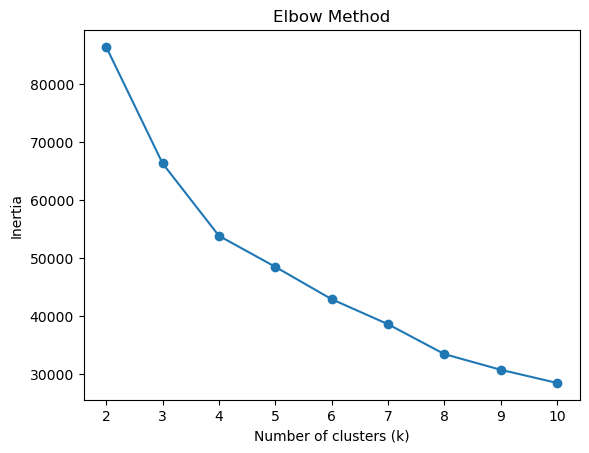

In [28]:
# Elbow method
inertia_scores = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia_scores.append(model.inertia_)

plt.plot(range(2, 11), inertia_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.savefig("Outputs/kmean_elbow.png", dpi=180)
plt.show()

In [29]:
# As the elbow method is a little inconlusive, we also implemented the silhouette score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# silhouette score
k_values = [3, 4]
models = [KMeans(n_clusters=k, random_state=42).fit(X) for k in k_values]

for model, k in zip(models, k_values):
    labels = model.predict(X)
    score = silhouette_score(X, labels)
    print(f"KMeans(n_clusters={k})")
    print(f"Silhouette score for k={k}: {score:.4f}\n")

KMeans(n_clusters=3)
Silhouette score for k=3: 0.2923

KMeans(n_clusters=4)
Silhouette score for k=4: 0.2864



In [30]:
# Fit KMeans clustering with three clusters
model = KMeans(n_clusters=3, random_state=random_state)
model.fit(X)

df2['Cluster_ID'] = model.predict(X)

print("Cluster centroids:")
for centroid in model.cluster_centers_:
    print(centroid)

Cluster centroids:
[0.47085978 1.01022309 0.27255469]
[-0.98913415 -0.10517814 -0.67210356]
[ 0.66682583 -0.82085023  0.49711181]


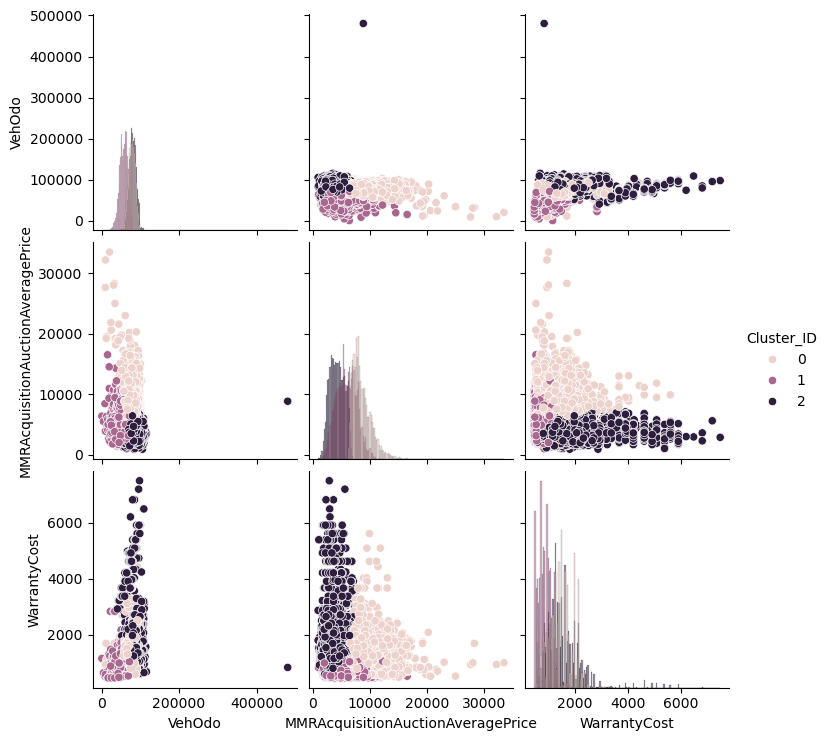

In [31]:
# Pairplot
sns.pairplot(df2, hue='Cluster_ID', diag_kind='hist')
plt.savefig("Outputs/kmeans_pairplot.png", dpi=180)
plt.show()

Distribution for cluster 0


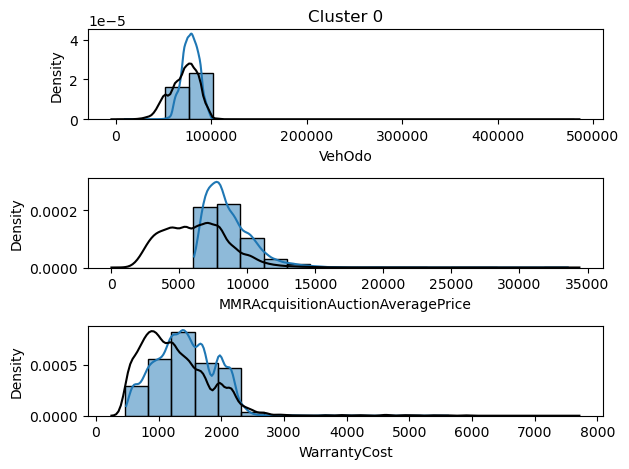

Distribution for cluster 1


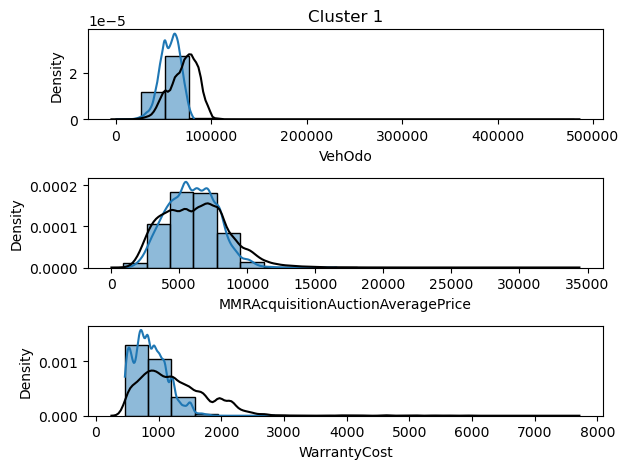

Distribution for cluster 2


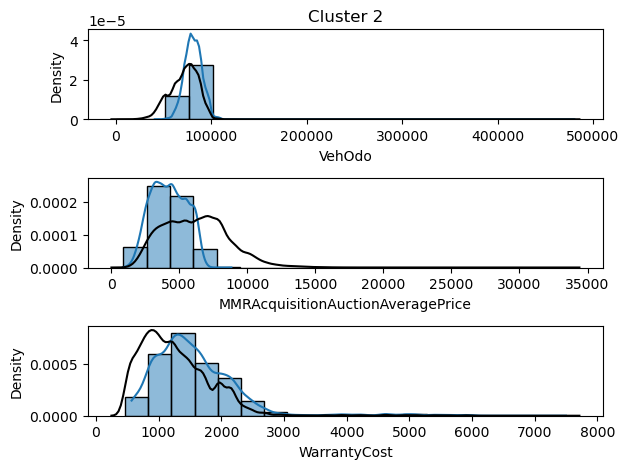

In [32]:
# Inspect clusters
def inspect_clusters(df, cols, clusters_to_inspect):
    n_bins = 20
    for cluster in clusters_to_inspect:
        print("Distribution for cluster {}".format(cluster))
        fig, ax = plt.subplots(nrows=len(cols))
        ax[0].set_title("Cluster {}".format(cluster))
        for j, col in enumerate(cols):
            bins = np.linspace(min(df[col]), max(df[col]), 20)
            sns.histplot(df[df['Cluster_ID'] == cluster][col], bins=bins,
                         ax=ax[j], kde=True, stat="density")
            sns.kdeplot(data=df[col], ax=ax[j], color="k")
        plt.tight_layout()
        plt.show()

inspect_clusters(df2, 
                 cols=['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'WarrantyCost'], 
                 clusters_to_inspect=[0, 1, 2])

New clustering model with the Make variable 

KPrototypes with Standardizing and K=3

In [33]:
selected_features = ['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'WarrantyCost', 'Make']
df2 = df[selected_features].copy()

df2['Make'] = df2['Make'].astype(str)

X = df2.to_numpy()

In [36]:
from kmodes.kprototypes import KPrototypes

kproto = KPrototypes(n_clusters=3, random_state=42)
clusters = kproto.fit_predict(X, categorical=[3]) 

df2['Cluster_ID'] = clusters

print("Cluster centroids:")
for idx, centroid in enumerate(kproto.cluster_centroids_):
    print(f"Cluster {idx}: {centroid}")

Cluster centroids:
Cluster 0: ['85448.83066055746' '6180.689003436426' '1514.2469135802469' 'CHEVROLET']
Cluster 1: ['69285.51784737002' '6212.752204317421' '1249.7900273639405' 'CHEVROLET']
Cluster 2: ['49656.78909465021' '6258.869455875629' '883.1978737997257' 'DODGE']


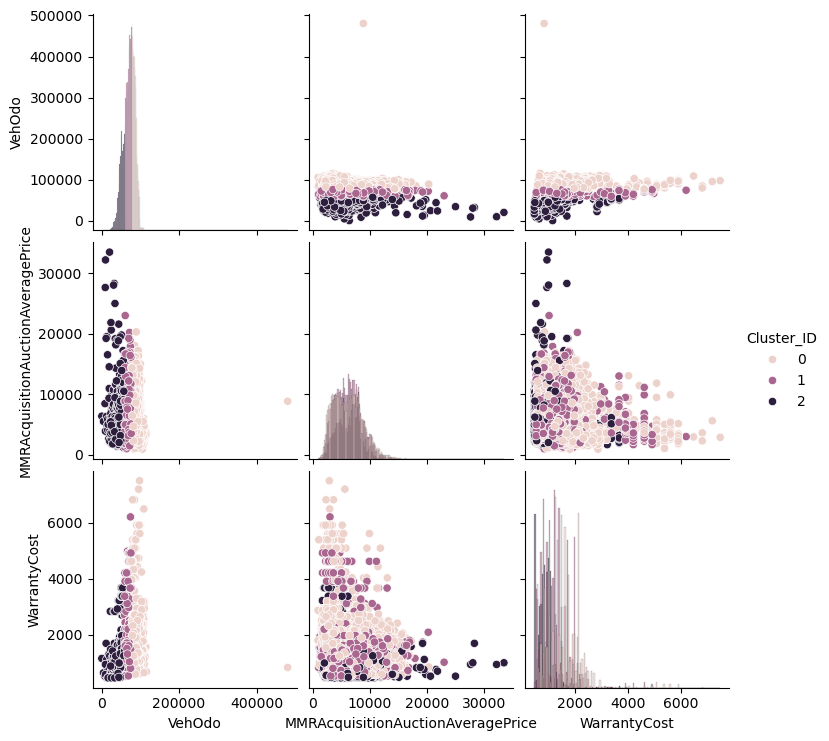

In [35]:
# Pairplot
sns.pairplot(df2, hue='Cluster_ID', diag_kind='hist')
plt.savefig("Outputs/kprototypes_pairplot.png", dpi=180)
plt.show()

# Task 3: Time Series Prediction using LSTM on the AgriWebb dataset

In [1]:
#pip install kmodes

In [1]:
import pandas as pd
sample_paddock_data= pd.read_csv("tsdm.csv")

In [2]:
# correcting the data types according to the varaible description table

sample_paddock_data["PADDOCK_ID"] = sample_paddock_data["PADDOCK_ID"].astype("string")

In [3]:
# converting a column with date as data type

sample_paddock_data["OBSERVATION_DATE"] = pd.to_datetime(sample_paddock_data["OBSERVATION_DATE"])

In [4]:
# sorting all the data with Paddock id first and then the observation date

sample_paddock_data = sample_paddock_data.sort_values(['PADDOCK_ID', 'OBSERVATION_DATE']).reset_index(drop=True)


In [5]:
# removing paddock ids with shorter sequence

seq_len = sample_paddock_data.groupby("PADDOCK_ID").size().rename("sequence_length")
max_len = int(seq_len.max())
valid_paddocks = seq_len[seq_len == max_len].index

before = sample_paddock_data["PADDOCK_ID"].nunique()
sample_paddock_data = sample_paddock_data[sample_paddock_data["PADDOCK_ID"].isin(valid_paddocks)].reset_index(drop=True)
after = sample_paddock_data["PADDOCK_ID"].nunique()

print(f"Total paddocks before filteration: {before}")
print(f"Paddocks removed: {before - after}")
print(f"Paddocks after filteration: {after}")

sample_paddock_data = sample_paddock_data[sample_paddock_data["PADDOCK_ID"].isin(valid_paddocks)].reset_index(drop=True)

Total paddocks before filteration: 19
Paddocks removed: 7
Paddocks after filteration: 12


In [6]:
sample_paddock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2340 entries, 0 to 2339
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   PADDOCK_ID          2340 non-null   string        
 1   OBSERVATION_DATE    2340 non-null   datetime64[ns]
 2   TSDM                2340 non-null   float64       
 3   15D_AVG_DAILY_RAIN  2340 non-null   float64       
 4   15D_AVG_MAX_TEMP    2340 non-null   float64       
 5   15D_AVG_MIN_TEMP    2340 non-null   float64       
 6   15D_AVG_RH_TMAX     2340 non-null   float64       
 7   15D_AVG_RH_TMIN     2340 non-null   float64       
 8   15D_AVG_EVAP_SYN    2340 non-null   float64       
 9   15D_AVG_RADIATION   2340 non-null   float64       
dtypes: datetime64[ns](1), float64(8), string(1)
memory usage: 182.9 KB


In [7]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence

def create_sequences(sequence, lookback, forecast_horizon, target_col, pad_value=0.0):
    T, num_features = sequence.shape
    X, y, lengths = [], [], []

    if lookback > 0:
        # Fixed-length lookback with pre-padding
        pad_vector = np.zeros((lookback, num_features))

        for t in range(1, T - forecast_horizon + 1):
            context = sequence[:t]
            if len(context) > lookback:
                context = context[-lookback:]

            padded_context = pad_vector.copy()
            padded_context[-len(context):] = context

            X.append(padded_context)
            y.append(sequence[t:t + forecast_horizon, target_col])
            lengths.append(min(len(context), lookback))

        return np.array(X), np.array(y), lengths

    else:
        # Full history with left pre-padding (variable-length inputs)
        for t in range(1, T - forecast_horizon + 1):
            context = torch.tensor(sequence[:t], dtype=torch.float32)
            lengths.append(t)

            X.append(context)  # No manual padding
            y.append(torch.tensor(sequence[t:t + forecast_horizon, target_col], dtype=torch.float32))

        X_padded = pad_sequence(X, batch_first=True, padding_value=pad_value)
        y_tensor = torch.stack(y)

        return X_padded.numpy(), y_tensor.numpy(), lengths

In [8]:
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

def data_prep(df, feature_columns, lookback, test_steps, target_col):
    # Prepare to store all training data
    X_all, y_all = [], []
    paddock_data_ids = []  # To track which paddock each sample comes from
    test_data = []  # To store test data for each paddock
    train_data = []
    lengths_all = []  # To store the lengths of each sequence for packing

    # Fit a global scaler 
    all_train_values = []
    for _, group in df.groupby("PADDOCK_ID"):
        feature_values = group[feature_columns].values
        if len(feature_values) > lookback + test_steps:
            all_train_values.append(feature_values[:-test_steps])
    all_train_values = np.vstack(all_train_values)

    global_scaler = MinMaxScaler()
    global_scaler.fit(all_train_values)
    
    # Process each paddocks's data
    for paddock_id, group in df.groupby('PADDOCK_ID'):
        feature_values = group[feature_columns].values

        # If there are not enough samples for training, skip this location
        if len(feature_values) <= 63:
            continue
            
        # Separate the last 5 steps for testing
        train_sample = global_scaler.transform(feature_values[:-test_steps])
        test_sample = global_scaler.transform(feature_values[-test_steps:])
        
        # If you prefer without scaling
        #train_sample = feature_values[:-test_steps]
        #test_sample = feature_values[-test_steps:]
        
        train_data.append((paddock_id, train_sample))
        test_data.append((paddock_id, test_sample, global_scaler))  # Store test data and scaler

        # Prepare LSTM sequence data for training
        X_paddock, y_paddock, lengths = create_sequences(train_sample, lookback, test_steps, target_col)

        # Append to the overall dataset
        X_all.append(X_paddock)
        y_all.append(y_paddock)
        lengths_all.append(lengths)  # Store sequence lengths

        # Store Location ID for tracking
        paddock_data_ids.extend([paddock_id] * len(y_paddock))

    # Concatenate all locations' training data for model training
    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)
    lengths_all = np.concatenate(lengths_all, axis=0)  # Concatenate sequence lengths

    # Reshape X to be [samples, time steps, features] as required by LSTM
    X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], X_all.shape[2]))  
    
    return torch.Tensor(X_all), torch.Tensor(y_all), torch.Tensor(lengths_all), train_data, test_data


In [9]:
lookback = 5
test_steps = 5
target_col = 0
X_5, y_5, lenghts_5, train_d_5, test_d_5 = data_prep(sample_paddock_data,['TSDM'],lookback,test_steps, target_col)

print("Shape of input data after sequence creation:", X_5.shape)
print("Shape of targets after sequence creation:", y_5.shape)

Shape of input data after sequence creation: torch.Size([2220, 5, 1])
Shape of targets after sequence creation: torch.Size([2220, 5])


In [10]:
# Defining the LSTM network
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class MyLSTMNet(nn.Module):
    def __init__(self, num_features, hidden_layer_size, num_layers, output_size, dropout_prob):
        super().__init__()
        self.lstm = nn.LSTM(input_size=num_features,  
                            hidden_size=hidden_layer_size,
                            num_layers=num_layers,
                            batch_first=True)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_layer_size, output_size)

    def forward(self, data, lengths):
        # Pack the input sequence - This ensures that the LSTM ignores padded values during computation.
        packed_data = pack_padded_sequence(data, lengths.cpu(), batch_first=True, enforce_sorted=False)

        # Run through LSTM
        packed_output, (hn, cn) = self.lstm(packed_data)

        # Use the last layer's hidden state
        last_hidden = hn[-1]  

        # Apply dropout and final linear layer
        out = self.dropout(last_hidden)
        out = self.fc(out)  
        return out


In [11]:
num_features = X_5.shape[2]
hidden_layer_size = 16
output_size = test_steps
num_layers = 1
dropout_prob = 0.2
model_lstm_5 = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)

In [12]:
print(model_lstm_5)

MyLSTMNet(
  (lstm): LSTM(1, 16, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=16, out_features=5, bias=True)
)


In [13]:
# defining the training process

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split

def train_predict_model(model, n_epochs, lr, X_all, y_all, lengths, validation_split=0.2):
    batch_size = 32

    # Split data into train and validation sets
    dataset = TensorDataset(X_all, y_all, lengths)
    val_size = int(len(dataset) * validation_split)
    train_size = len(dataset) - val_size
    train_set, val_set = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    print(f"The model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")

    train_loss_history = []
    val_loss_history = []

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(n_epochs):
        model.train()
        for X_batch, y_batch, lengths_batch in train_loader:
            y_pred = model(X_batch, lengths_batch)
            loss = loss_fn(y_pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation check every 100 epochs
        if epoch % 100 == 0:
            model.eval()
            with torch.no_grad():
                train_preds = model(X_all[train_set.indices], lengths[train_set.indices])
                train_loss = loss_fn(train_preds, y_all[train_set.indices]).item()

                val_preds = model(X_all[val_set.indices], lengths[val_set.indices])
                val_loss = loss_fn(val_preds, y_all[val_set.indices]).item()

                print(f"Epoch {epoch+1}: train loss {train_loss:.4f}, val loss {val_loss:.4f}")

                train_loss_history.append(train_loss)
                val_loss_history.append(val_loss)

                # Save best model
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_model_state = model.state_dict()

    # Restore best model state
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_loss_history, val_loss_history, model


In [14]:
n_epochs = 501
lr = 0.001
train_loss_history_5,val_loss_history_5, model_lstm_5 = train_predict_model(model_lstm_5, n_epochs, 
                                                                            lr, X_5, y_5, lenghts_5,
                                                                            validation_split=0.2)

The model has 1,301 trainable parameters
Epoch 1: train loss 0.0264, val loss 0.0274
Epoch 101: train loss 0.0141, val loss 0.0148
Epoch 201: train loss 0.0131, val loss 0.0139
Epoch 301: train loss 0.0128, val loss 0.0137
Epoch 401: train loss 0.0126, val loss 0.0135
Epoch 501: train loss 0.0126, val loss 0.0135


In [15]:
def vis_train_loss(train_loss_history, val_loss_history):
    epochs = range(0, n_epochs, 100) 
    plt.plot(epochs, train_loss_history, label='Training Loss')
    plt.plot(epochs, val_loss_history, label='Validation Loss')  # <-- add this line
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Convergence')
    plt.legend()
    plt.grid()
    plt.show()

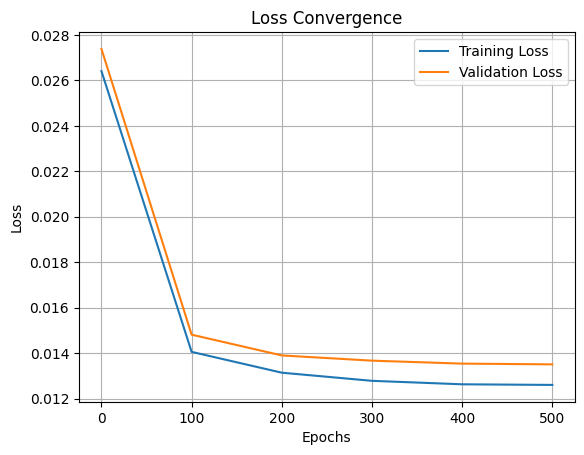

In [16]:
vis_train_loss(train_loss_history_5, val_loss_history_5)

In [17]:
# computing the RMSE
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
def pred_eval(model, X, y, lengths, train_d, test_d, lookback, target_col):
    model.eval()
    with torch.no_grad():
        train_preds = model(X, lengths)
        print("Training RMSE:",root_mean_squared_error(y.flatten().tolist(),train_preds.flatten().tolist()))
        print("Training R2:", r2_score(y.flatten().tolist(),train_preds.flatten().tolist()))
        X_test = []
        y_test = []
        lengths_test = []
        for count, (location_id, test_values, scaler) in enumerate(test_d):
            train_values = train_d[count][1]
            X_test.append(train_values[-lookback:])
            y_test.append(test_values[:,target_col])
            # Append the actual lengths (just like the training phase)
            lengths_test.append(len(train_values[-lookback:]))  
        X_test = torch.Tensor(np.array(X_test)) 
        y_test = torch.Tensor(np.array(y_test))
        lengths_test = torch.Tensor(lengths_test).long()
        test_preds = model(X_test,lengths_test)
        #print(y_test.flatten().tolist())
        #print(test_preds.flatten().tolist())
        print("Test RMSE:",root_mean_squared_error(y_test.flatten().tolist(),test_preds.flatten().tolist()))
        print("Test R2:", r2_score(y_test.flatten().tolist(),test_preds.flatten().tolist()))
        plt.figure(figsize=(10, 6))
        plt.plot(y_test.flatten().tolist(), label="Expected Value")
        plt.plot(test_preds.flatten().tolist(), label="Predicted Value")
        plt.grid()
        plt.legend(fontsize=10)
        plt.tight_layout()
        plt.show()


Training RMSE: 0.11305217503112933
Training R2: 0.5355503644594537
Test RMSE: 0.12887532394977252
Test R2: 0.25743629086187814


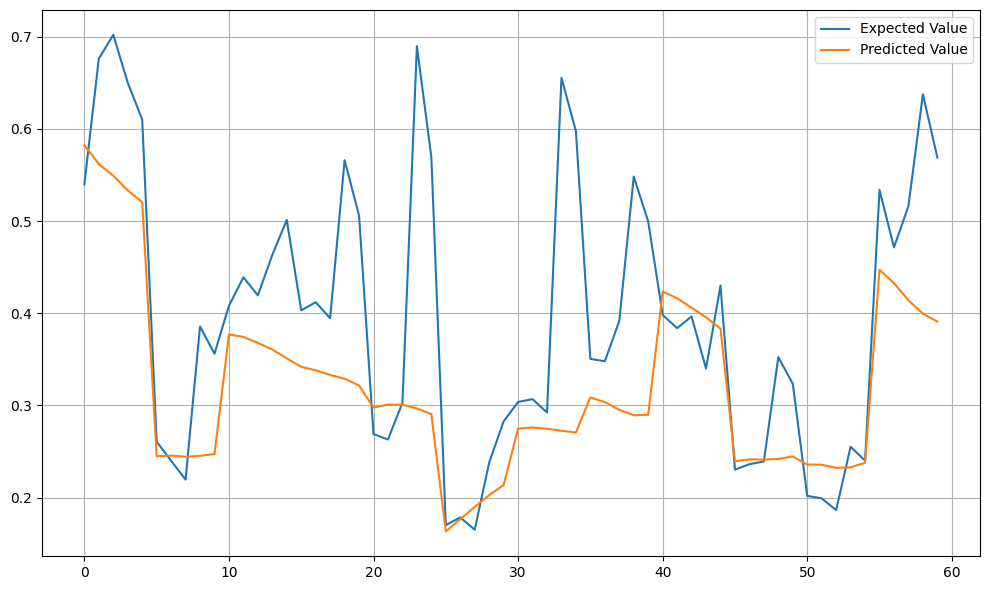

In [18]:
lookback = 5
target_col = 0
pred_eval(model_lstm_5, X_5, y_5, lenghts_5, train_d_5, test_d_5, lookback, target_col)

**LSTM model with Lookback=10**

In [19]:
# another Univariative LSTM mode with changed parameter
lookback = 10
test_steps = 5
target_col = 0
X_10, y_10, lenghts_10, train_d_10, test_d_10 = data_prep(sample_paddock_data,['TSDM'],lookback,test_steps, target_col)

print("Shape of input data after sequence creation:", X_10.shape)
print("Shape of targets after sequence creation:", y_10.shape)

Shape of input data after sequence creation: torch.Size([2220, 10, 1])
Shape of targets after sequence creation: torch.Size([2220, 5])


In [20]:
num_features = X_10.shape[2]
hidden_layer_size = 16
output_size = test_steps
num_layers = 2
dropout_prob = 0.2
model_lstm_10 = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)

In [21]:
print(model_lstm_10)

MyLSTMNet(
  (lstm): LSTM(1, 16, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=16, out_features=5, bias=True)
)


In [22]:
n_epochs = 501
lr = 0.001
train_loss_history_10,val_loss_history_10, model_lstm_10 = train_predict_model(model_lstm_10, n_epochs, 
                                                                            lr, X_10, y_10, lenghts_10,
                                                                            validation_split=0.2)

The model has 3,477 trainable parameters
Epoch 1: train loss 0.0277, val loss 0.0301
Epoch 101: train loss 0.0128, val loss 0.0136
Epoch 201: train loss 0.0122, val loss 0.0136
Epoch 301: train loss 0.0112, val loss 0.0124
Epoch 401: train loss 0.0099, val loss 0.0117
Epoch 501: train loss 0.0083, val loss 0.0116


In [23]:
def vis_train_loss(train_loss_history, val_loss_history):
    epochs = range(0, n_epochs, 100) 
    plt.plot(epochs, train_loss_history, label='Training Loss')
    plt.plot(epochs, val_loss_history, label='Validation Loss')  # <-- add this line
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Convergence')
    plt.legend()
    plt.grid()
    plt.show()

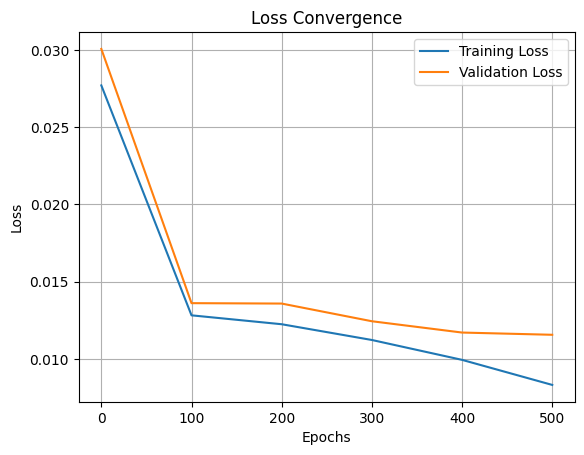

In [24]:
vis_train_loss(train_loss_history_10, val_loss_history_10)

Training RMSE: 0.09468088020081925
Training R2: 0.6742342999972069
Test RMSE: 0.1179775898462167
Test R2: 0.37770942982664435


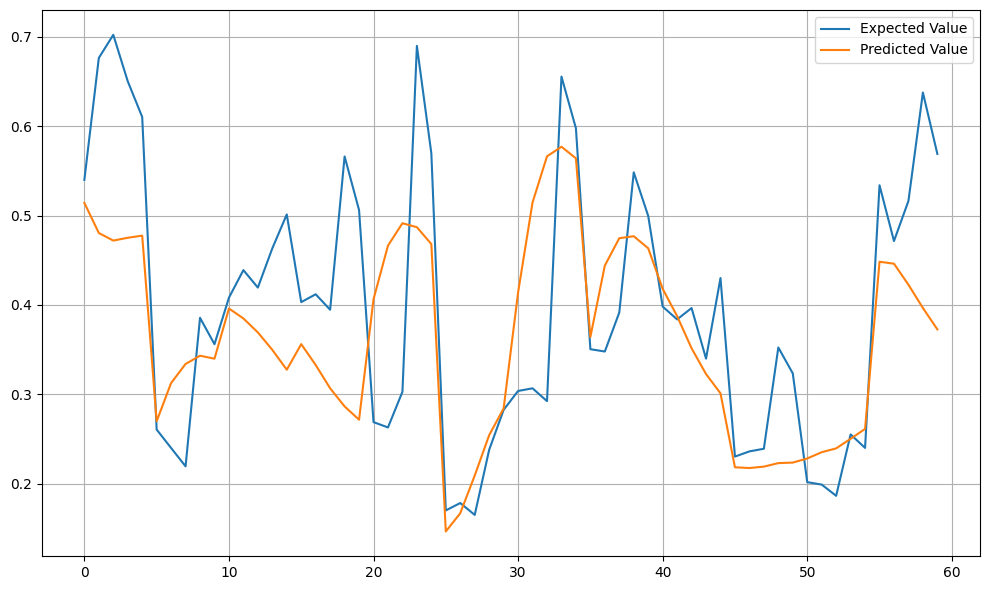

In [25]:
lookback = 10
target_col = 0
pred_eval(model_lstm_10, X_10, y_10, lenghts_10, train_d_10, test_d_10, lookback, target_col)

**Multivariate LSTM model**

Shape of input data after sequence creation: torch.Size([2220, 5, 8])
Shape of targets after sequence creation: torch.Size([2220, 5])
The model has 3,925 trainable parameters
Epoch 1: train loss 0.0265, val loss 0.0258
Epoch 101: train loss 0.0089, val loss 0.0094
Epoch 201: train loss 0.0063, val loss 0.0071
Epoch 301: train loss 0.0054, val loss 0.0063
Epoch 401: train loss 0.0045, val loss 0.0056
Epoch 501: train loss 0.0039, val loss 0.0051


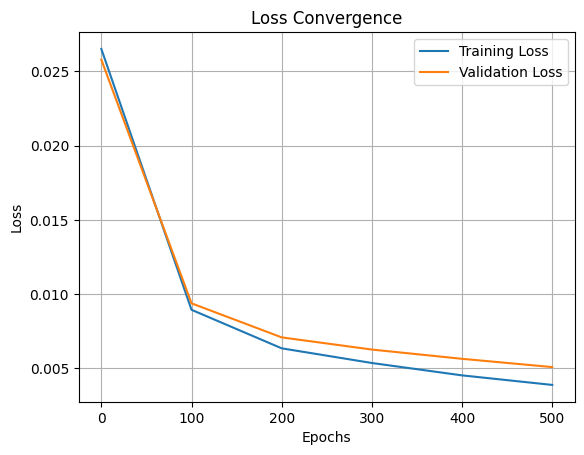

Training RMSE: 0.06421158962781834
Training R2: 0.8501669483377264
Test RMSE: 0.1223746009941368
Test R2: 0.33045964530307204


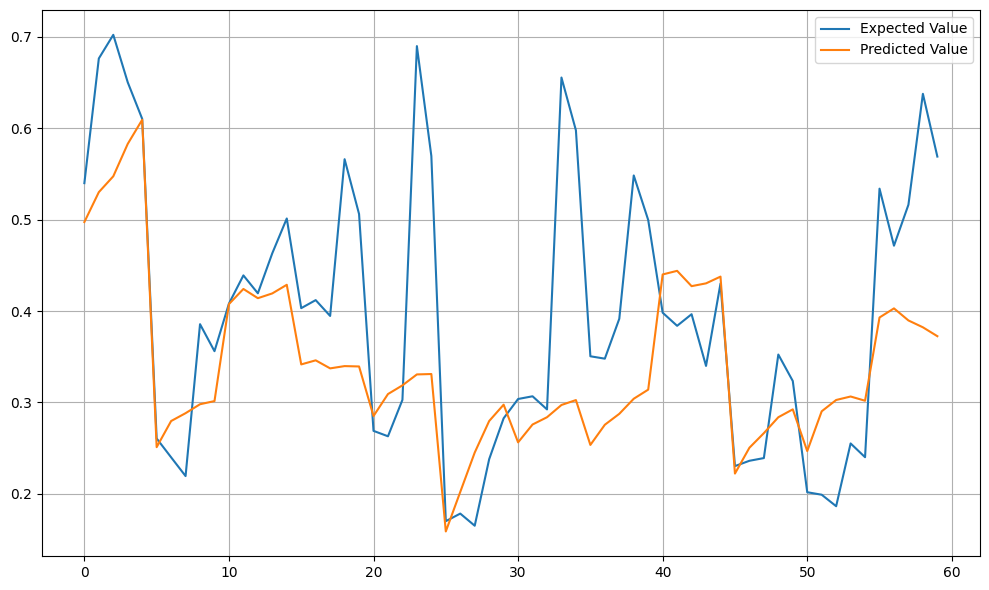

In [26]:
# Look back is set to 5
lookback = 5
test_steps = 5
target_col = 0
X_5_mv, y_5_mv, lenghts_5_mv, train_d_5_mv, test_d_5_mv = data_prep(sample_paddock_data,['TSDM', '15D_AVG_DAILY_RAIN',
       '15D_AVG_MAX_TEMP', '15D_AVG_MIN_TEMP', '15D_AVG_RH_TMAX',
       '15D_AVG_RH_TMIN', '15D_AVG_EVAP_SYN', '15D_AVG_RADIATION'],
                                                                    lookback,test_steps, target_col)

print("Shape of input data after sequence creation:", X_5_mv.shape)
print("Shape of targets after sequence creation:", y_5_mv.shape)

num_features = X_5_mv.shape[2]
hidden_layer_size = 16
output_size = test_steps
n_epochs = 501
lr = 0.001
num_layers = 2
dropout_prob = 0.2

model_lstm_5_mv = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)
train_loss_history_5_mv,val_loss_history_5_mv, model_lstm_5_mv = train_predict_model(model_lstm_5_mv, 
                                                                                     n_epochs, lr, X_5_mv, 
                                                                                     y_5_mv, lenghts_5_mv,
                                                                                     validation_split=0.2)
vis_train_loss(train_loss_history_5_mv, val_loss_history_5_mv)
pred_eval(model_lstm_5_mv, X_5_mv, y_5_mv, lenghts_5_mv, train_d_5_mv, test_d_5_mv, lookback, target_col)

Shape of input data after sequence creation: torch.Size([2220, 10, 8])
Shape of targets after sequence creation: torch.Size([2220, 5])
The model has 1,749 trainable parameters
Epoch 1: train loss 0.0262, val loss 0.0264
Epoch 101: train loss 0.0081, val loss 0.0084
Epoch 201: train loss 0.0055, val loss 0.0061
Epoch 301: train loss 0.0046, val loss 0.0053
Epoch 401: train loss 0.0039, val loss 0.0047
Epoch 501: train loss 0.0038, val loss 0.0047


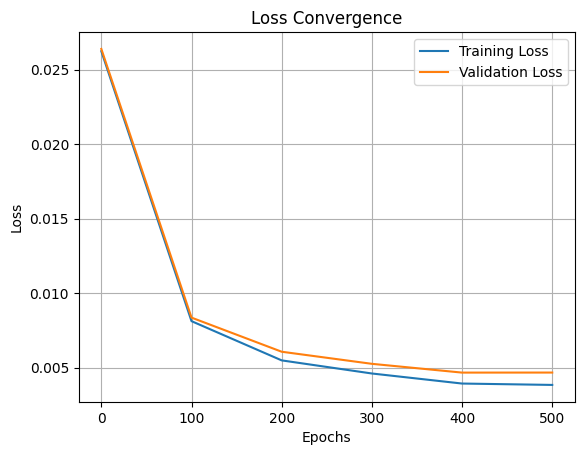

Training RMSE: 0.0633576479326577
Training R2: 0.8541256699409174
Test RMSE: 0.09084997018831162
Test R2: 0.6309852220317642


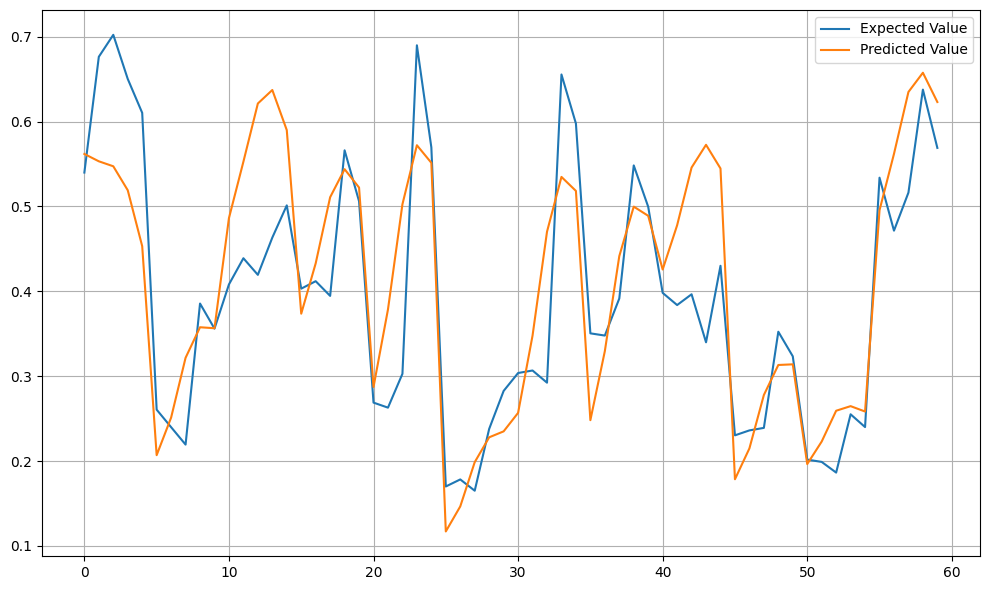

In [27]:
# your code here
lookback = 10
test_steps = 5
target_col = 0
X_10_mv, y_10_mv, lenghts_10_mv, train_d_10_mv, test_d_10_mv = data_prep(sample_paddock_data,['TSDM', '15D_AVG_DAILY_RAIN',
       '15D_AVG_MAX_TEMP', '15D_AVG_MIN_TEMP', '15D_AVG_RH_TMAX',
       '15D_AVG_RH_TMIN', '15D_AVG_EVAP_SYN', '15D_AVG_RADIATION'],
                                                                         lookback,test_steps, target_col)
print("Shape of input data after sequence creation:", X_10_mv.shape)
print("Shape of targets after sequence creation:", y_10_mv.shape)

num_features = X_10_mv.shape[2]
hidden_layer_size = 16
output_size = test_steps
n_epochs = 501
lr = 0.001
num_layers = 1
dropout_prob = 0.2
model_lstm_10_mv = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)

train_loss_history_10_mv,val_loss_history_10_mv, model_lstm_10_mv = train_predict_model(model_lstm_10_mv, n_epochs, 
                                                                                        lr, X_10_mv, y_10_mv, 
                                                                                        lenghts_10_mv,
                                                                                        validation_split=0.2)

vis_train_loss(train_loss_history_10_mv, val_loss_history_10_mv)

pred_eval(model_lstm_10_mv, X_10_mv, y_10_mv, lenghts_10_mv, train_d_10_mv, test_d_10_mv, lookback, target_col)

Shape of input data after sequence creation: torch.Size([2220, 185, 8])
Shape of targets after sequence creation: torch.Size([2220, 5])
The model has 1,749 trainable parameters
Epoch 1: train loss 0.0257, val loss 0.0261
Epoch 101: train loss 0.0062, val loss 0.0070
Epoch 201: train loss 0.0050, val loss 0.0058
Epoch 301: train loss 0.0039, val loss 0.0046
Epoch 401: train loss 0.0036, val loss 0.0041
Epoch 501: train loss 0.0033, val loss 0.0039


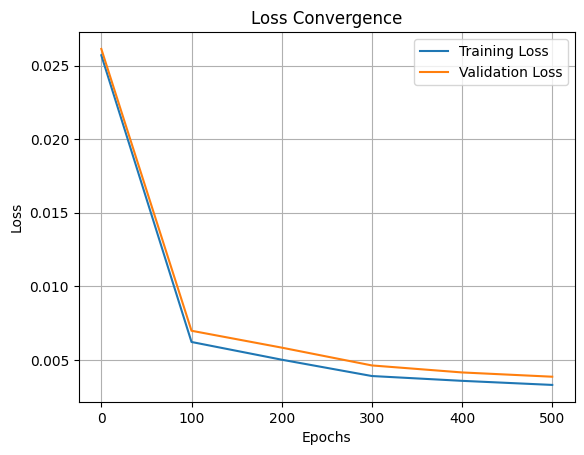

Training RMSE: 0.05841683027280579
Training R2: 0.8759899854579011
Test RMSE: 0.08735586187327737
Test R2: 0.6588241467802234


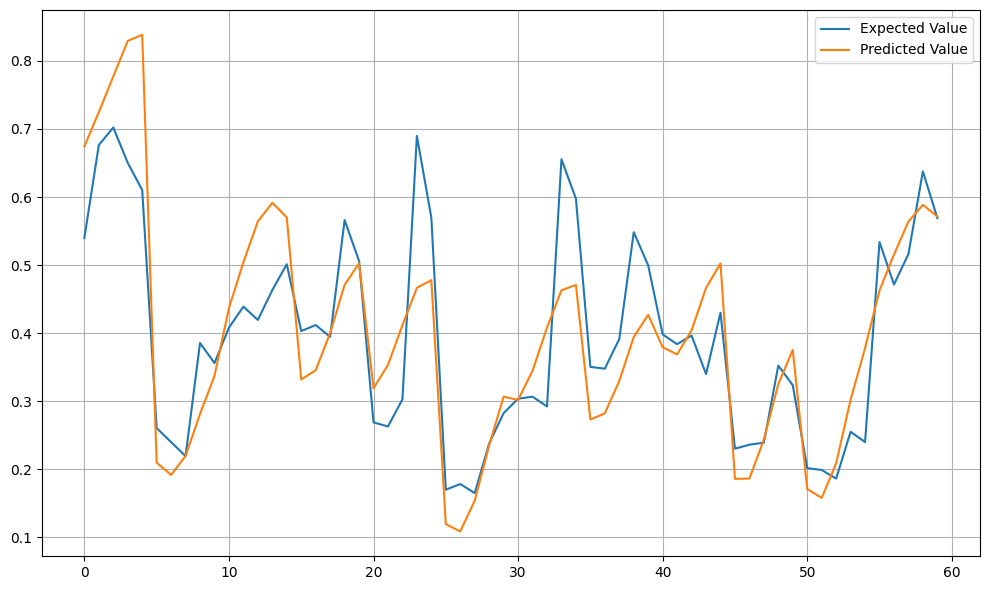

In [28]:
lookback = 0 # Means no restriction of lookback
target_col = 0
X_f, y_f,lengths_f, train_d_f, test_d_f = data_prep(sample_paddock_data,['TSDM', '15D_AVG_DAILY_RAIN',
       '15D_AVG_MAX_TEMP', '15D_AVG_MIN_TEMP', '15D_AVG_RH_TMAX',
       '15D_AVG_RH_TMIN', '15D_AVG_EVAP_SYN', '15D_AVG_RADIATION'],lookback,test_steps, target_col)

print("Shape of input data after sequence creation:", X_f.shape)
print("Shape of targets after sequence creation:", y_f.shape)

num_features = X_f.shape[2]
hidden_layer_size = 16
output_size = test_steps
n_epochs = 501
lr = 0.001
num_layers = 1
dropout_prob = 0.2
model_lstm_f = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)

train_loss_history_f,val_loss_history_f,model_lstm_f = train_predict_model(model_lstm_f, n_epochs, 
                                                                           lr, X_f, y_f, lengths_f, 
                                                                           validation_split=0.2)

vis_train_loss(train_loss_history_f, val_loss_history_f)

pred_eval(model_lstm_f, X_f, y_f, lengths_f, train_d_f, test_d_f, lookback, target_col)

# Task 4: Hydrogen Tweet Classification with BERT

In [27]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, accuracy_score
torch.cuda.empty_cache()

In [2]:
#pip install ipywidgets

In [3]:
#pip install transformers

In [4]:
#pip install datasets

In [5]:
#pip install 'accelerate>=0.26.0'

In [6]:
df = pd.read_csv("Datasets/hydrogen_small.csv")
print(df.head())

# Convert labels to integers
df['label'] = df['label'].map({'Relevant': 1, 'Irrelevant': 0})

# Train-test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

print("Train size:", len(train_df))
print("Test size:", len(test_df))

print("Full distribution (counts):")
print(df["label"].value_counts(dropna=False))

        label                                               text
0    Relevant         behind the wheel of a hydrogen powered car
1  Irrelevant  mls measurements of stratospheric hydrogen cya...
2    Relevant  ana gonzalez hernandez shares an overview of h...
3    Relevant  toyota is giving away its first hydrogen car i...
4    Relevant  agility develops storage systems for hydrogen ...
Train size: 800
Test size: 200
Full distribution (counts):
label
1    547
0    453
Name: count, dtype: int64


First model

Preparing the datasets

In [7]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",  
        max_length=max_len
    )

In [8]:
train_ds = Dataset.from_pandas(train_df, preserve_index=False)
test_ds  = Dataset.from_pandas(test_df,  preserve_index=False)

model_name = "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

max_len = tokenizer.model_max_length

train_ds = train_ds.map(tokenize, batched=True, remove_columns=["text"])
test_ds  = test_ds.map(tokenize,  batched=True, remove_columns=["text"])

train_ds = train_ds.rename_column("label", "labels")
test_ds  = test_ds.rename_column("label", "labels")
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format(type="torch",  columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [9]:
# Loading the first model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    problem_type="single_label_classification"
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    prec, recall, f1, _ = precision_recall_fscore_support(
    labels, preds, average="binary", pos_label=1)
    return {
    "accuracy": acc,
    "precision": prec,
    "recall": recall,
    "f1": f1
    }

Training

In [11]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",          
    save_strategy="epoch",
    load_best_model_at_end=True,         
    metric_for_best_model="eval_f1",     
    greater_is_better=True,               
    fp16=True,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
)

In [12]:
model.train()
trainer = Trainer(
model=model,
args=training_args,
train_dataset=train_ds,
eval_dataset=test_ds,
processing_class=tokenizer,
data_collator=DataCollatorWithPadding(tokenizer),
compute_metrics=compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.233100,0.675581,0.860000,0.809160,0.972477,0.883333
2,0.552500,0.356748,0.930000,0.920354,0.954128,0.936937
3,0.130800,0.464911,0.925000,0.919643,0.944954,0.932127
4,0.016700,0.513731,0.920000,0.911504,0.944954,0.927928
5,0.004900,0.605149,0.910000,0.888889,0.954128,0.920354


TrainOutput(global_step=1000, training_loss=0.21166791149973868, metrics={'train_runtime': 163.7872, 'train_samples_per_second': 24.422, 'train_steps_per_second': 6.105, 'total_flos': 529869594624000.0, 'train_loss': 0.21166791149973868, 'epoch': 5.0})

In [13]:
model.eval()
train_results1 = trainer.evaluate(train_ds)
test_results1 = trainer.evaluate(test_ds)

def display_evaluation(setname, results):
    print(f"{setname} Set Accuracy:", round(results["eval_accuracy"], 3))
    print(f"{setname} Set Precision:", round(results["eval_precision"], 3))
    print(f"{setname} Set Recall:", round(results["eval_recall"], 3))
    print(f"{setname} Set F1 score:", round(results["eval_f1"], 3))
    
display_evaluation("Training", train_results1)
display_evaluation("Testing", test_results1)

Training Set Accuracy: 0.98
Training Set Precision: 0.977
Training Set Recall: 0.986
Training Set F1 score: 0.982
Testing Set Accuracy: 0.93
Testing Set Precision: 0.92
Testing Set Recall: 0.954
Testing Set F1 score: 0.937


Second model

Prepare data

In [14]:
train_ds = Dataset.from_pandas(train_df, preserve_index=False)
test_ds  = Dataset.from_pandas(test_df,  preserve_index=False)

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

max_len = tokenizer.model_max_length

train_ds = train_ds.map(tokenize, batched=True, remove_columns=["text"])
test_ds  = test_ds.map(tokenize,  batched=True, remove_columns=["text"])

train_ds = train_ds.rename_column("label", "labels")
test_ds  = test_ds.rename_column("label", "labels")
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format(type="torch",  columns=["input_ids", "attention_mask", "labels"])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [15]:
# Loading the second model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    problem_type="single_label_classification"
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [16]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",          
    save_strategy="epoch",
    load_best_model_at_end=True,         
    metric_for_best_model="eval_f1",     
    greater_is_better=True,               
    fp16=True,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
)

In [17]:
model.train()
trainer = Trainer(
model=model,
args=training_args,
train_dataset=train_ds,
eval_dataset=test_ds,
processing_class=tokenizer,
data_collator=DataCollatorWithPadding(tokenizer),
compute_metrics=compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.232500,0.394249,0.885000,0.877193,0.917431,0.896861
2,0.444600,0.333188,0.925000,0.943396,0.917431,0.930233
3,0.007100,0.481598,0.905000,0.875000,0.963303,0.917031
4,0.001600,0.495502,0.910000,0.882353,0.963303,0.921053
5,0.112400,0.500442,0.910000,0.882353,0.963303,0.921053


TrainOutput(global_step=1000, training_loss=0.16129819840192794, metrics={'train_runtime': 151.1158, 'train_samples_per_second': 26.47, 'train_steps_per_second': 6.617, 'total_flos': 529869594624000.0, 'train_loss': 0.16129819840192794, 'epoch': 5.0})

In [18]:
model.eval()
train_results2 = trainer.evaluate(train_ds)
test_results2 = trainer.evaluate(test_ds)

display_evaluation("Training", train_results2)
display_evaluation("Testing", test_results2)

Training Set Accuracy: 0.978
Training Set Precision: 0.995
Training Set Recall: 0.963
Training Set F1 score: 0.979
Testing Set Accuracy: 0.925
Testing Set Precision: 0.943
Testing Set Recall: 0.917
Testing Set F1 score: 0.93


Attention Weights

DistilBertSdpaAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


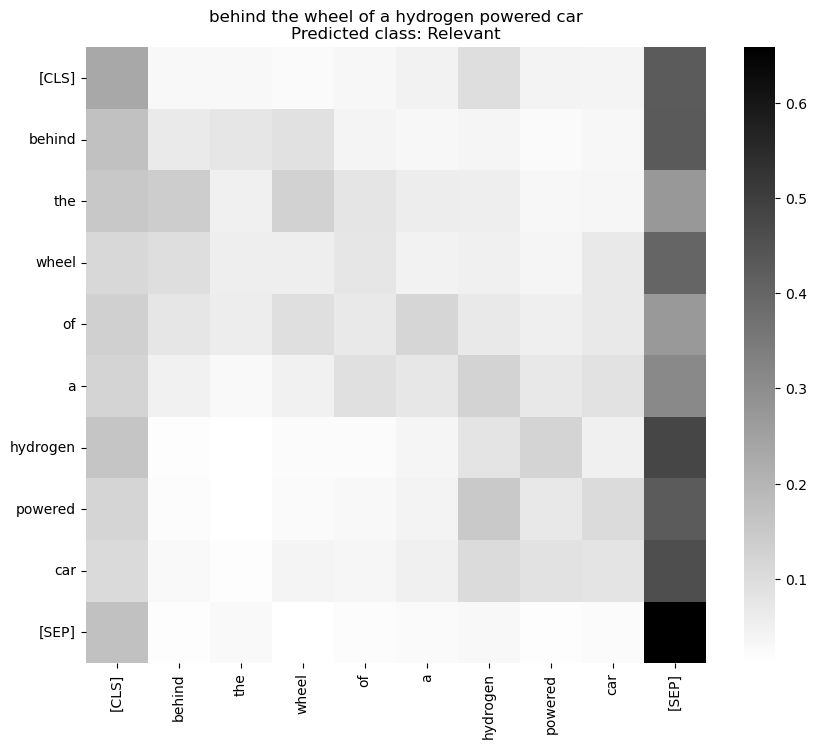

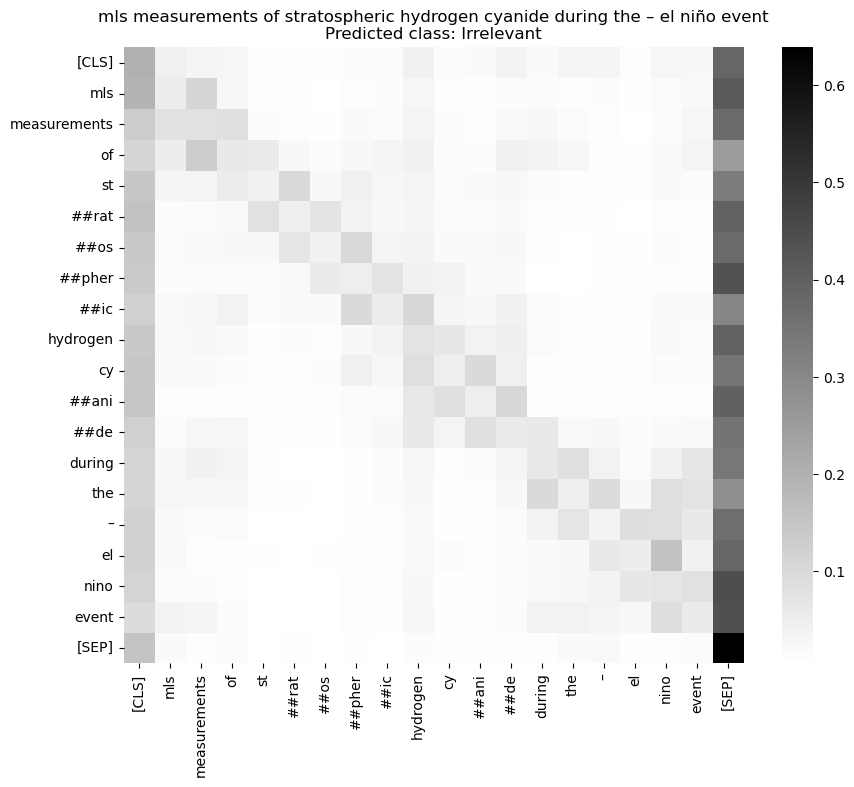

In [20]:
def compute_attention_matrix(tokenizer, model, text):
    tokens = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**tokens, output_attentions=True)
    attentions = torch.stack(outputs.attentions).cpu()
    attentions = attentions.squeeze(1)
    attentions = attentions.mean(dim=0).mean(dim=0)
    pred_class = outputs.logits.cpu().argmax(-1).item()
    token_strs = tokenizer.convert_ids_to_tokens(tokens["input_ids"][0])
    return attentions, pred_class, token_strs

def plot_attention(attentions, tokens, title):
    plt.figure(figsize=(10, 8))
    plt.title(title)
    sns.heatmap(
        attentions,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='binary',
        cbar=True
    )
    plt.xticks(rotation=90)
    plt.show()

def display_attention_matrix(tokenizer, model, text):
    attentions, pred_class, tokens = compute_attention_matrix(tokenizer, model, text)
    pred_label = "Relevant" if pred_class == 1 else "Irrelevant"
    plot_attention(attentions, tokens, text + f"\nPredicted class: {pred_label}")

relevant_text = df[df["label"] == 1].iloc[0]["text"]
display_attention_matrix(tokenizer, model, relevant_text)

irrelevant_text = df[df["label"] == 0].iloc[0]["text"]
display_attention_matrix(tokenizer, model, irrelevant_text)


Logistic regression model

In [25]:
X = pd.read_csv("Datasets/tfidf_features_small.csv")
labels_df = pd.read_csv("Datasets/hydrogen_small.csv")

y = labels_df["label"].map({'Relevant': 1, 'Irrelevant': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


ROC curves

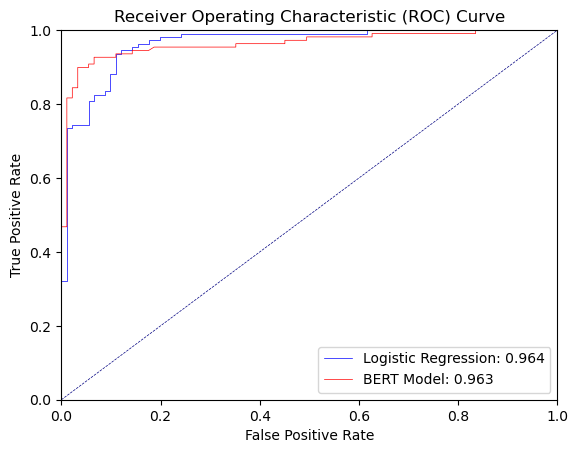

In [31]:
# LR
logit_probs = clf.predict_proba(X_test)[:, 1]  
y_pred = clf.predict(X_test)                   
y_test_lr = y_test.values                      
roc_index_lr = roc_auc_score(y_test_lr, logit_probs)
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test_lr, logit_probs)

# BERT
pred = trainer.predict(test_ds)
bert_probs = torch.nn.functional.softmax(torch.Tensor(pred.predictions), dim=-1).numpy()
bert_pred_labels = np.argmax(pred.predictions, axis=-1)
y_test_bert = pred.label_ids
roc_index_bert = roc_auc_score(y_test_bert, bert_probs[:, 1])
fpr_bert, tpr_bert, thresholds_bert = roc_curve(y_test_bert, bert_probs[:, 1])

# Plot ROC curves
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression: {:.3f}".format(roc_index_lr), color="blue", lw=0.5)
plt.plot(fpr_bert, tpr_bert, label="BERT Model: {:.3f}".format(roc_index_bert), color="red", lw=0.5)
plt.plot([0, 1], [0, 1], color="navy", lw=0.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

In [35]:
# Compare both models with an accuracy table
accuracy_lr = accuracy_score(y_test_lr, y_pred)
accuracy_bert = accuracy_score(y_test_bert, bert_pred_labels)

print("\nAccuracy Table")
print("{:<24} {:<12} {:<10}".format("Model", "Accuracy", "AUC-ROC"))
print("{:<24} {:.3f}        {:.3f}".format("Logistic Regression", accuracy_lr, roc_index_lr))
print("{:<24} {:.3f}        {:.3f}".format("BERT Model", accuracy_bert, roc_index_bert))

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test_lr, y_pred, target_names=["Irrelevant", "Relevant"]))

print("\nBERT Model Classification Report:")
print(classification_report(y_test_bert, bert_pred_labels, target_names=["Irrelevant", "Relevant"]))



Accuracy Table
Model                    Accuracy     AUC-ROC   
Logistic Regression      0.910        0.964
BERT Model               0.925        0.963

Logistic Regression Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.95      0.85      0.90        91
    Relevant       0.88      0.96      0.92       109

    accuracy                           0.91       200
   macro avg       0.92      0.90      0.91       200
weighted avg       0.91      0.91      0.91       200


BERT Model Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.90      0.93      0.92        91
    Relevant       0.94      0.92      0.93       109

    accuracy                           0.93       200
   macro avg       0.92      0.93      0.92       200
weighted avg       0.93      0.93      0.93       200



# Prepare SQuAD_tiny Dataset for Assignment 2

This code prepare SQuAD_tiny from the SQuAD dataset. 

# 0. Import libraries

In [2]:
#!pip install datasets

In [4]:
#!pip install transformers rouge-score

In [6]:
#!pip install sentencepiece

In [8]:
#pip install 'accelerate>=0.26.0'

In [9]:
import os
import torch
import shutil
import gc
import numpy as np
from datasets import load_dataset
from transformers import T5Tokenizer, T5ForConditionalGeneration, Trainer, TrainingArguments, DataCollatorForSeq2Seq, EarlyStoppingCallback
from rouge_score import rouge_scorer
from tqdm import tqdm
from transformers import logging as transformers_logging
from itertools import batched
import pandas as pd
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

In [10]:
# Set seed for reproducibility
torch.manual_seed(42)


# 1. Load and preprocess SQuAD dataset

In [11]:
# 1. Load and preprocess SQuAD dataset
dataset = load_dataset("squad")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

In [12]:
# Take subsets to avoid overload
train_dataset = dataset["train"].select(range(10000,11000))
val_dataset = dataset["validation"].select(range(3000,3100))
test_dataset = dataset["validation"].select(range(3100, 3200))  # No official SQuAD test set

In [13]:
print("Size of training set:", len(train_dataset))
print("Size of validation set:", len(val_dataset))
print("Size of testing set:", len(test_dataset))

Size of training set: 1000
Size of validation set: 100
Size of testing set: 100


In [14]:
MODEL_NAME = "t5-small"
#MODEL_NAME = "t5-base"
MAX_INPUT_LENGTH = 512
MAX_OUTPUT_LENGTH = 128
# Load tokenizer and model
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [15]:
def encode_question_and_context(question, context):
    return f"question: {question}  context: {context}"

# Obtains the context, question and answer from a given sample.
def extract_sample_parts(sample):
    context = sample["context"]
    question = sample["question"]
    answer = sample["answers"]['text'][0]
    question_with_context = encode_question_and_context(question, context)
    return (question_with_context, question, answer)

# Encodes the sample, returning token IDs.
def preprocess(sample):
    # Extract data from sample.
    question_with_context, question, answer = extract_sample_parts(sample)

    # Using truncation causes the tokenizer to emit a warning for every sample.
    # This will generate a significant amount of messages, and likely crash
    # your browser tab. We temporarily disable log messages to work around this.
    # See https://github.com/huggingface/transformers/issues/14285
    old_level = transformers_logging.get_verbosity()
    transformers_logging.set_verbosity_error()
    
    # Generate tokens for the input.
    # We include both the context and the question (first two parameters).
    input_tokens = tokenizer(question_with_context, question, padding="max_length",
                             truncation=True, max_length=MAX_INPUT_LENGTH)

    # Generate tokens for the expected answer. There is no need to include the 
    output_tokens = tokenizer(answer, padding="max_length", truncation=True,
                              max_length=MAX_OUTPUT_LENGTH)

    # Restore old logging level, see above.
    transformers_logging.set_verbosity(old_level)

    # The output of the tokenizer is a map containing {input_ids, attention_mask}.
    # For trianing, we need to add the labels (answer/output tokens) to the map.
    input_tokens["labels"] = np.array(output_tokens["input_ids"])

    return input_tokens

In [16]:
# Preprocess the datasets
training_set_enc = train_dataset.map(preprocess, batched=False)
validation_set_enc = val_dataset.map(preprocess, batched=False)
testing_set_enc = test_dataset.map(preprocess, batched=False)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Save the datasets to use them in task5.ipynb

2. Fine-Tuning the T5 model

In [17]:
# Use PyTorch tensors to improve the performance of the training process
cols = ["input_ids", "attention_mask", "labels"]
training_set_enc.set_format(type="torch", columns=cols)
validation_set_enc.set_format(type="torch", columns=cols)
testing_set_enc.set_format(type="torch", columns=cols)

In [18]:
# to use less memory
model.config.use_cache = False

To prevent overfitting we used Early Stopping

In [19]:
# Avoid conflicts with an already existing results directory
if os.path.exists("./results"):
    shutil.rmtree("./results")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model.config.use_cache = False

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    pad_to_multiple_of=8
)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=30,                  
    
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    eval_accumulation_steps=8,
    dataloader_num_workers=0,
    
    eval_strategy="epoch",                
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    learning_rate=1e-4,
    weight_decay=0.01,
    save_total_limit=2,
    logging_dir="./logs",
    logging_steps=10,
    overwrite_output_dir=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=training_set_enc,
    eval_dataset=validation_set_enc,
    tokenizer=tokenizer,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)
trainer.train(resume_from_checkpoint=False)

/tmp/ipykernel_1358/1832176544.py:42: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/opt/conda/lib/python3.12/site-packages/transformers/data/data_collator.py:741: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Epoch,Training Loss,Validation Loss
1,0.118200,0.071445
2,0.024000,0.021100
3,0.019900,0.020924
4,0.016600,0.020308
5,0.012800,0.021668
6,0.012000,0.021705
7,0.015700,0.023966
8,0.011600,0.022760
9,0.010700,0.024127


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=1125, training_loss=0.20698019218444824, metrics={'train_runtime': 710.5461, 'train_samples_per_second': 42.221, 'train_steps_per_second': 5.278, 'total_flos': 1218076213248000.0, 'train_loss': 0.20698019218444824, 'epoch': 9.0})

Evaluation on the test set

In [20]:
def compute_average_score(scores, metric, key):
     total = 0
     for i in range(len(scores)):
         total += getattr(scores[i][metric], key)
     return total / len(scores)

def compute_rouge(predictions, references):
    metrics = ["rouge1", "rouge2", "rougeL"]
    
    scorer = rouge_scorer.RougeScorer(metrics, use_stemmer=True)
    
    scores = []
    for prediction, reference in zip(predictions, references):
        scores.append(scorer.score(prediction, reference))

    results = {}
    for metric in metrics:
        for k in ["precision", "recall", "fmeasure"]:
            results[f"{metric}_{k}"] = compute_average_score(
                scores, metric, k)
    return results

In [21]:
model.eval()
answers_ctx, refs_ctx = [], []

for ex in test_dataset: 
    q, c = ex["question"], ex["context"]
    ref = ex["answers"]["text"][0] if ex["answers"]["text"] else ""
    inp = encode_question_and_context(q, c)

    toks = tokenizer(inp, return_tensors="pt", truncation=True, max_length=512)
    if torch.cuda.is_available():
        toks = {k: v.to("cuda") for k, v in toks.items()}

    with torch.no_grad():
        out = model.generate(**toks, max_new_tokens=64, num_beams=4, early_stopping=True)

    pred = tokenizer.decode(out[0], skip_special_tokens=True).strip()
    answers_ctx.append(pred.replace("\n", " "))
    refs_ctx.append(ref.replace("\n", " "))

In [22]:
rouge_ctx = compute_rouge(answers_ctx, refs_ctx)
print("ROUGE (with context):", rouge_ctx)

ROUGE (with context): {'rouge1_precision': 0.7147838827838826, 'rouge1_recall': 0.7508333333333335, 'rouge1_fmeasure': 0.7124629912571088, 'rouge2_precision': 0.47408333333333325, 'rouge2_recall': 0.517, 'rouge2_fmeasure': 0.47967460317460314, 'rougeL_precision': 0.7147838827838826, 'rougeL_recall': 0.7508333333333335, 'rougeL_fmeasure': 0.7124629912571088}


Generative Analysis on Test Samples

In [23]:
def generate_response(tokenizer, model, question):
    tokenized = tokenizer(question, return_tensors="pt", padding=True, truncation=True, max_length=MAX_OUTPUT_LENGTH).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**tokenized)
    outputs = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    return outputs

def generate_answers(tokenizer, model, dataset, use_context=True, limit=None):
    if limit is not None:
        dataset = dataset.select(range(limit))
    questions = []
    inputs = []
    references = []
    for sample in dataset:
        question_with_context, question, answer = extract_sample_parts(sample)
        if use_context:
            inputs.append(question_with_context)
        else:
            inputs.append(question)
        questions.append(question)
        references.append(answer)
    outputs = []
    for samples in batched(inputs, 128):
        responses = generate_response(tokenizer, model, list(samples))
        outputs.extend(responses)
    assert (len(outputs) == len(references))
    return outputs, references, questions
     

In [24]:
# Generate answers with context
answers_ctx, refs_ctx, questions_ctx = generate_answers(
    tokenizer, model, test_dataset, use_context=True, limit=5
)
# Generate answers without context
answers_noctx, refs_noctx, questions_noctx = generate_answers(
    tokenizer, model, test_dataset, use_context=False, limit=5
)

In [25]:
for i, (q, gold, pred_ctx, pred_q) in enumerate(zip(questions_ctx, refs_ctx, answers_ctx, answers_noctx)):
    print(f"=== Test sample {i} ===")
    print("Question:", q)
    print("Gold answer:", gold)
    print("Pred (with context):", pred_ctx)
    print("Pred (question only):", pred_q)
    print()

=== Test sample 0 ===
Question: What country initially received the largest number of Huguenot refugees?
Gold answer: the Dutch Republic
Pred (with context): Dutch Republic
Pred (question only): 

=== Test sample 1 ===
Question: How many refugees emigrated to the Dutch Republic?
Gold answer: an estimated total of 75,000 to 100,000 people
Pred (with context): 2 million
Pred (question only): Wie viele Flüchtlinge emigrierten in die Niederlande?

=== Test sample 2 ===
Question: What was the population of the Dutch Republic before this emigration?
Gold answer: ca. 2 million
Pred (with context): ca. 2 million
Pred (question only): 

=== Test sample 3 ===
Question: What two areas in the Republic were first to grant rights to the Huguenots?
Gold answer: Amsterdam and the area of West Frisia
Pred (with context): the village of Fraissinet-de-Lozère
Pred (question only): were the first to grant rights to the Huguenots?

=== Test sample 4 ===
Question: What declaration predicated the emigration o

Comparison with a pretrained model

In [29]:
# a. Load Pre-trained model
# PRETRAINED_ID = "mrm8488/t5-base-finetuned-squadv2" (checkpoints of this model weren't loaded correctly)
PRETRAINED_ID = "MaRiOrOsSi/t5-base-finetuned-question-answering"
pre_tok = AutoTokenizer.from_pretrained(PRETRAINED_ID)
pre_model = AutoModelForSeq2SeqLM.from_pretrained(PRETRAINED_ID)
device = "cuda" if torch.cuda.is_available() else "cpu"
pre_model.to(device)
# pre_model.eval()

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
              (dropout): Dro

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

In [30]:
# b. Replicate the evaluation steps from Tasks 3 and 4
pre_answers_ctx, pre_refs_ctx = [], []

for ex in test_dataset: 
    q, c = ex["question"], ex["context"]
    ref = ex["answers"]["text"][0] if ex["answers"]["text"] else ""
    inp = encode_question_and_context(q, c)

    toks = pre_tok(inp, return_tensors="pt", truncation=True, max_length=512)
    toks = {k: v.to(device) for k, v in toks.items()}

    with torch.no_grad():
        out = pre_model.generate(**toks, max_new_tokens=64, num_beams=4, early_stopping=True)

    pred = pre_tok.decode(out[0], skip_special_tokens=True).strip()
    pre_answers_ctx.append(pred.replace("\n", " "))
    pre_refs_ctx.append(ref.replace("\n", " "))

In [31]:
pre_rouge_ctx = compute_rouge(pre_answers_ctx, pre_refs_ctx)
print("ROUGE on pretrained Model (test, with context):", pre_rouge_ctx)

ROUGE on pretrained Model (test, with context): {'rouge1_precision': 0.7764624542124543, 'rouge1_recall': 0.8439880952380951, 'rouge1_fmeasure': 0.7840716783216783, 'rouge2_precision': 0.4585555555555555, 'rouge2_recall': 0.5106666666666667, 'rouge2_fmeasure': 0.46921300921300924, 'rougeL_precision': 0.7750338827838829, 'rougeL_recall': 0.8406547619047618, 'rougeL_fmeasure': 0.7820716783216785}


In [32]:
# c. Compare its performance against your fine-tuned SQuAD_tiny model in a table 

tiny = rouge_ctx        
pre  = pre_rouge_ctx    

cols = [
    "rouge1_precision","rouge1_recall","rouge1_fmeasure",
    "rouge2_precision","rouge2_recall","rouge2_fmeasure",
    "rougeL_precision","rougeL_recall","rougeL_fmeasure"
]

df = pd.DataFrame.from_dict(
    {
        "SQuAD_tiny": {k: tiny.get(k, float("nan")) for k in cols},
        "Pretrained": {k: pre.get(k, float("nan")) for k in cols},
    },
    orient="index"
)[cols]

df = df.rename(columns={
    "rouge1_precision":"R1 Prec", "rouge1_recall":"R1 Rec", "rouge1_fmeasure":"R1 F1",
    "rouge2_precision":"R2 Prec", "rouge2_recall":"R2 Rec", "rouge2_fmeasure":"R2 F1",
    "rougeL_precision":"RL Prec", "rougeL_recall":"RL Rec", "rougeL_fmeasure":"RL F1",
})

df.round(3)


,R1 Prec,R1 Rec,R1 F1,R2 Prec,R2 Rec,R2 F1,RL Prec,RL Rec,RL F1
SQuAD_tiny,0.715,0.751,0.712,0.474,0.517,0.480,0.715,0.751,0.712
Pretrained,0.776,0.844,0.784,0.459,0.511,0.469,0.775,0.841,0.782


In [ ]:
pre_answers_ctx 

In [30]:
pre_refs_ctx

['the Dutch Republic',
 'an estimated total of 75,000 to 100,000 people',
 'ca. 2 million',
 'Amsterdam and the area of West Frisia',
 'the revocation of the Edict of Nantes',
 'Tours',
 'Huguon',
 'the ghost of le roi Huguet',
 'prétendus réformés',
 'night',
 'Canterbury',
 'The Weavers',
 'economic separation',
 'Kent, particularly Sandwich, Faversham and Maidstone',
 'a restaurant',
 'Cork City',
 'Dublin, Cork, Youghal and Waterford',
 'Dublin',
 'a High Sheriff and one of the founders of the Bank of Ireland',
 '1696',
 'brain drain',
 'New France',
 'non-Catholics',
 "Seven Years' War",
 '1759-60',
 'Henry of Navarre',
 '1598',
 'granted the Protestants equality with Catholics',
 'the founding of new Protestant churches',
 'Protestantism',
 'education of children as Catholics',
 'prohibited emigration',
 'Four thousand',
 '"new converts"',
 'Holland, Prussia, and South Africa',
 'Switzerland and the Netherlands',
 '1555',
 'France Antarctique',
 '1560',
 'the Guanabara Confession

In [28]:
# Install packages
%pip install -U "transformers[torch]" "accelerate>=0.26.0"
%pip install -U datasets sentencepiece rouge-score evaluate
%pip install datasets transformers sentencepiece rouge-score
%pip install protobuf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 421.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 645.7 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.53.3
    Uninstalling transformers-4.53.3:╺━━━━━━━━━━━━━━━━━━━ 1/2 [transformers]
      Successfully uninstalled transformers-4.53.3━━━━━━━━━━━━━━━━ 1/2 [transformers]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [transformers] [transformers]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
